In [1]:
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
from tqdm import tqdm

EXCLUDED_PATIENTS = ['AJ7TSV9','AS2MVDL']
order = ['ATHKM6V', 'AUY8KYW', 'AURCTAK', 'AX6281V', 'AOYM4KG', 'A4G0044', 'A7EM0B6', 'AQC0L71', 'AZIK4ZA', 'AHYIJDV', 'AAXAA7Z', 'A1ZJ41O', 'AFPB8J2', 'ASFODQR', 'A0VFT1N', 'AJWW3IY', 'AV2GF3B', 'AKXN5ZZ', 'A1K5DRI', 'A4E0D03', 'APGIB2T', 'A3OU183', 'AYWIEKR', 'A0NVTRV', 'AIFDJZB', 'A36HR6Y', 'AA2KP1S', 'AJMQUVV', 'AMV7EQF', 'AYEFCWQ']

In [ ]:
class Heatmap:

    patient_metrics_df = None
    patients = []
    mechanisms = ['MCAR', 'MAR_l', 'MAR_m', 'MAR_h', 'MNAR_l', 'MNAR_m', 'MNAR_h']
    mec_labels = {}
    mr_values = ["05", "10", "15", "20", "25"]
    n = 5

    def __init__(self, metric):
        self.metric = metric
        self.pmetrics_df()

        for mec in self.mechanisms:
            if "_" in mec:
                base, sub = mec.split("_")
                mec_label = rf"{base}$_{{{sub.upper()}}}$"
            else:
                mec_label = mec
            self.mec_labels[mec] = mec_label

    def _intervals_overlap(self, a, b):
        """Verifica se os intervalos a e b se sobrepõem"""
        return max(a[0], b[0]) <= min(a[1], b[1])

    def _match_event_intervals(self, y_true, y_pred):
        """
        Compara listas de intervalos (eventos reais e previstos).
        Cada intervalo é uma tupla: (inicio, fim)

        Retorna TP, FP, FN
        """
        matched = set()

        for i, pred in enumerate(y_pred):
            for j, true in enumerate(y_true):
                if self._intervals_overlap(pred, true):
                    matched.add(j)
                    break  # conta só uma correspondência

        TP = len(matched)
        FP = len(y_pred) - TP
        FN = len(y_true) - TP

        return TP, FP, FN

    def pmetrics_df(self):
        
        self.patients = [patient for patient in os.listdir(f"Patients/{self.metric}") 
                         if os.path.isdir(os.path.join(f"Patients/{self.metric}", patient))
                         and patient not in EXCLUDED_PATIENTS]
        self.patients.sort(key=lambda x: order.index(x))
        patient_metrics = {}

        failed = []
        for patient in self.patients:
            try:
                df_full = pd.read_csv(f'Patients/{self.metric}/{patient}/Anomalies/{patient}_original_anomalies.csv', usecols=[1, 2], header=None)
            except (FileNotFoundError, pd.errors.EmptyDataError):
                failed.append(patient)
                continue

            metrics_by_mec = {}
            for mec in self.mechanisms:
                metrics_by_mr = []
                for mr in self.mr_values:
                    tp_sum = fp_sum = fn_sum = 0
                    count = 0
                    for i in range(1, self.n + 1):
                        file_path = f'Patients/{self.metric}/{patient}/Anomalies/{mec}/{i}/{patient}_anomalies_{mec}_{i}_{mr}.csv'
                        if not os.path.exists(file_path) or os.path.getsize(file_path) == 0:
                            continue
                        try:
                            df_miss = pd.read_csv(file_path, usecols=[1, 2], header=None)
                        except pd.errors.EmptyDataError:
                            continue

                        y_true_intervals = [(pd.to_datetime(start), pd.to_datetime(start)) for start in df_full[1]]
                        y_pred_intervals = [(pd.to_datetime(start), pd.to_datetime(start)) for start in df_miss[1]]

                        TP, FP, FN = self._match_event_intervals(y_true_intervals, y_pred_intervals)
                        tp_sum += TP
                        fp_sum += FP
                        fn_sum += FN
                        count += 1

                    if count > 0:
                        accuracy = tp_sum / (tp_sum + fp_sum + fn_sum) if (tp_sum + fp_sum + fn_sum) > 0 else 0
                        precision = tp_sum / (tp_sum + fp_sum) if (tp_sum + fp_sum) > 0 else 0
                        recall = tp_sum / (tp_sum + fn_sum) if (tp_sum + fn_sum) > 0 else 0
                        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
                    else:
                        accuracy = precision = recall = f1 = 0

                    metrics_by_mr.append({
                        'MR': mr,
                        'Accuracy': accuracy * 100,
                        'Precision': precision * 100,
                        'Recall': recall * 100,
                        'F1_Score': f1 * 100
                    })
                metrics_by_mec[mec] = pd.DataFrame(metrics_by_mr)
            patient_metrics[patient] = metrics_by_mec

        for patient in failed:
            self.patients.remove(patient)

        records = []
        for patient, mec_dict in patient_metrics.items():
            for mec, df in mec_dict.items():
                for _, row in df.iterrows():
                    records.append({
                        'Patient': patient,
                        'MEC': mec,
                        'MR': row['MR'],
                        'Accuracy': row['Accuracy'],
                        'Precision': row['Precision'],
                        'Recall': row['Recall'],
                        'F1_Score': row['F1_Score']
                    })
        self.patient_metrics_df = pd.DataFrame(records)

    def plot_heatmap(self, metric):

        # Define which patients should appear in bold
        bold_patients = ['AIFDJZB', 'A36HR6Y', 'AYEFCWQ']  #rhr
        #bold_patients = ['AV2GF3B', 'AMV7EQF', 'ASFODQR'] #hros
        patient_labels = {p: f'$\\mathbf{{{p}}}$' if p in bold_patients else p for p in self.patients}

        # Troca o eixo: MR no índice, MEC nas colunas
        self.patient_metrics_df['MR'] = pd.Categorical(self.patient_metrics_df['MR'], categories=self.mr_values, ordered=True)
        heatmap_data = {}
        for mec in self.mechanisms:
            df_pivot = self.patient_metrics_df[self.patient_metrics_df['MEC'] == mec].pivot(index='MR', columns='Patient', values=metric)
            df_pivot = df_pivot.loc[self.mr_values, self.patients]
            heatmap_data[mec] = df_pivot

        fig, axes = plt.subplots(len(self.mechanisms), 1, figsize=(18, 10), sharex=True, sharey=True, gridspec_kw={'hspace': 0.3})

        vmin = min(df.min().min() for df in heatmap_data.values())
        vmax = max(df.max().max() for df in heatmap_data.values())

        for ax, (mec, df) in zip(axes, heatmap_data.items()):
            sns.heatmap(df, ax=ax, cmap='RdYlBu', vmin=vmin, vmax=vmax, cbar=False, annot=True, fmt=".1f")

            ax.set_title(f'{self.mec_labels.get(mec, mec)}', fontsize=10)
            ax.set_ylabel('')
            if ax == axes[3]:
                ax.set_ylabel('Missing Rate (%)', fontsize=9)
            ax.set_xlabel('')
            if ax == axes[-1]:
                ax.set_xlabel('')
            ax.set_yticklabels(df.index, rotation=0)
            ax.set_xticklabels([patient_labels.get(p, p) for p in df.columns], rotation=90, fontsize=9)


        cbar = fig.colorbar(
            axes[0].collections[0],
            ax=axes,
            orientation='vertical',
            fraction=0.025,
            pad=0.02,
            aspect=30
        )
        cbar.set_label(f'{metric} (%)', fontsize=12)
        plt.savefig(f'Plots/Heatmaps/Heatmap_{self.metric}_{metric}.eps', dpi=300, bbox_inches='tight')
    
    
    def plot_pheatmap(self, patient = 'AIFDJZB'):
        patient_spec = self.patient_metrics_df[self.patient_metrics_df['Patient'] == patient]
        metrics = ['Accuracy', 'Precision', 'Recall', 'F1_Score']
        fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharey=True)
        plt.subplots_adjust(wspace=0.1, hspace=0.4)

        for idx, metric in enumerate(metrics):
            ax = axes[idx // 2, idx % 2]
            patient_pivot = patient_spec.pivot(index='MEC', columns='MR', values=metric)
            sns.heatmap(patient_pivot, cmap='RdYlBu', cbar=False, annot=True, fmt=".1f", vmin=0, vmax=100, ax=ax, cbar_kws={'label': f'{metric} (%)'} if idx == 3 else None)
            ax.set_title(metric)
            ax.set_xlabel('', fontsize=9)

        for ax in axes.flat:
            ax.set_ylabel('')

        cbar = fig.colorbar(
            axes[0, 0].collections[0],
            ax=axes,
            orientation='vertical',
            fraction=0.025,
            pad=0.02,
            aspect=30,
            label='Percentage (%)'
        )

        plt.savefig(f'Plots/Heatmaps/Heatmap_{self.metric}_{patient}.eps', bbox_inches='tight', dpi=300)
        

In [9]:
def plot_heatmap(hm,metric):

    # Define which patients should appear in bold
    #bold_patients = ['AIFDJZB', 'A36HR6Y', 'AYEFCWQ']  #rhr
    bold_patients = ['AV2GF3B', 'AMV7EQF', 'ASFODQR'] #hros
    patient_labels = {p: f'$\\mathbf{{{p}}}$' if p in bold_patients else p for p in hm.patients}

    # Troca o eixo: MR no índice, MEC nas colunas
    hm.patient_metrics_df['MR'] = pd.Categorical(hm.patient_metrics_df['MR'], categories=hm.mr_values, ordered=True)
    heatmap_data = {}
    for mec in hm.mechanisms:
        df_pivot = hm.patient_metrics_df[hm.patient_metrics_df['MEC'] == mec].pivot(index='MR', columns='Patient', values=metric)
        df_pivot = df_pivot.loc[hm.mr_values, hm.patients]
        heatmap_data[mec] = df_pivot

    fig, axes = plt.subplots(len(hm.mechanisms), 1, figsize=(18, 10), sharex=True, sharey=True, gridspec_kw={'hspace': 0.3})

    vmin = min(df.min().min() for df in heatmap_data.values())
    vmax = max(df.max().max() for df in heatmap_data.values())

    for ax, (mec, df) in zip(axes, heatmap_data.items()):
        sns.heatmap(df, ax=ax, cmap='RdYlBu', vmin=vmin, vmax=vmax, cbar=False, annot=True, fmt=".1f")

        ax.set_title(f'{hm.mec_labels.get(mec, mec)}', fontsize=10)
        ax.set_ylabel('')
        if ax == axes[3]:
            ax.set_ylabel('Missing Rate (%)', fontsize=9)
        ax.set_xlabel('')
        if ax == axes[-1]:
            ax.set_xlabel('')
        ax.set_yticklabels(df.index, rotation=0)
        ax.set_xticklabels([patient_labels.get(p, p) for p in df.columns], rotation=90, fontsize=9)
        
    cbar = fig.colorbar(
        axes[0].collections[0],
        ax=axes,
        orientation='vertical',
        fraction=0.025,
        pad=0.02,
        aspect=30
    )
    cbar.set_label(f'{metric} (%)', fontsize=12)
    plt.savefig(f'Plots/Heatmaps/Heatmap_{hm.metric}_{metric}.eps', dpi=300, bbox_inches='tight')
    

In [3]:
%%time
results_rhr = Heatmap("RHR")

CPU times: user 16min 46s, sys: 421 ms, total: 16min 47s
Wall time: 16min 47s


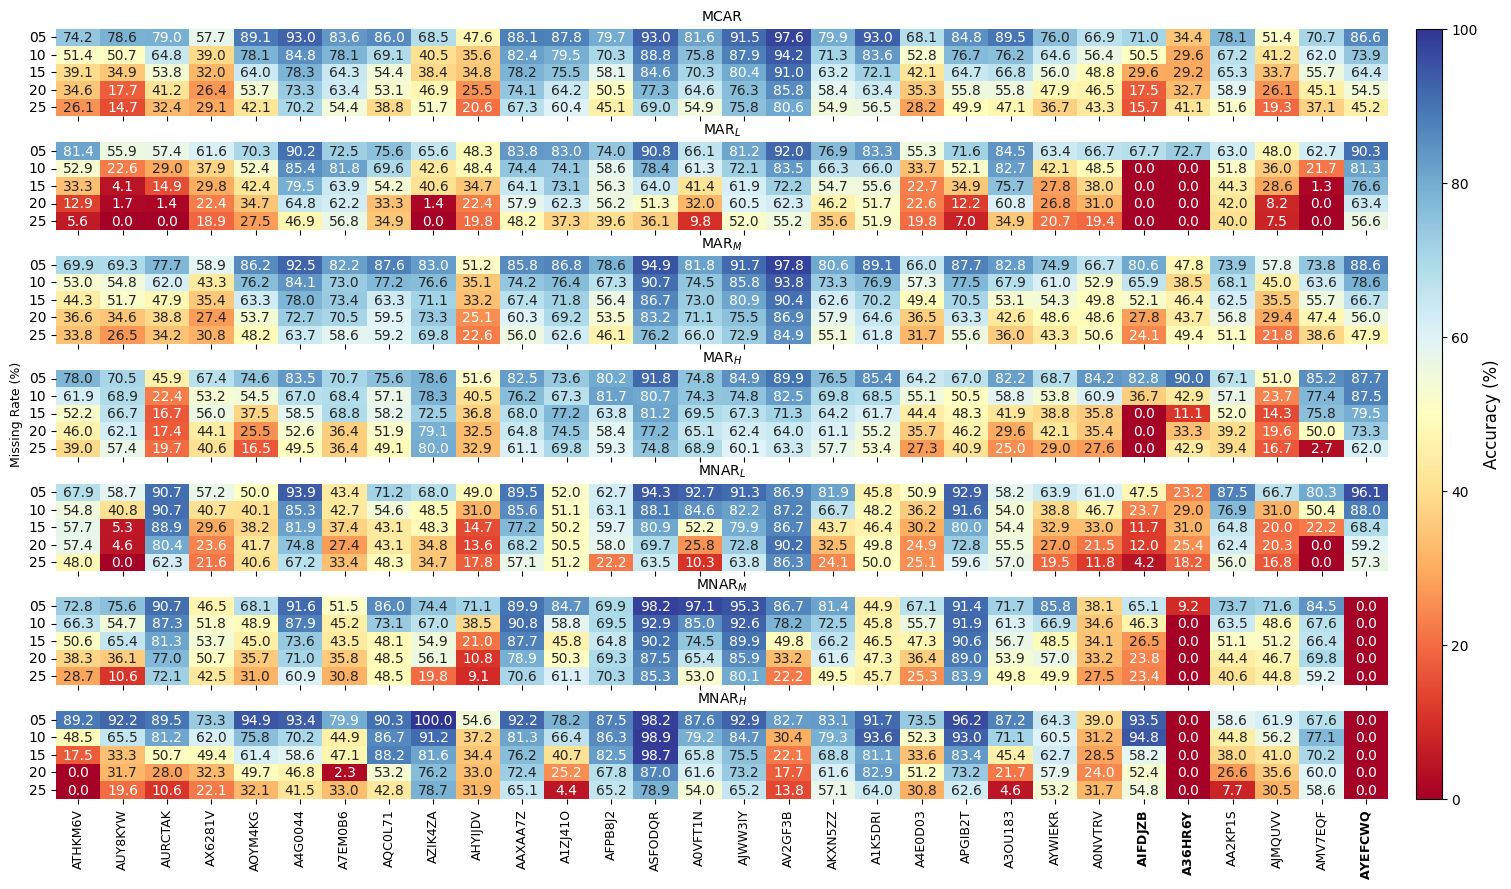

In [8]:
#results_rhr.plot_heatmap("Accuracy")
plot_heatmap(results_rhr,"Accuracy")
# results_rhr.plot_heatmap("F1_Score")
# results_rhr.plot_heatmap("Recall")
# results_rhr.plot_heatmap("Precision")


In [10]:
%%time
results_hros = Heatmap("HROS")

CPU times: user 18min 29s, sys: 311 ms, total: 18min 29s
Wall time: 18min 29s


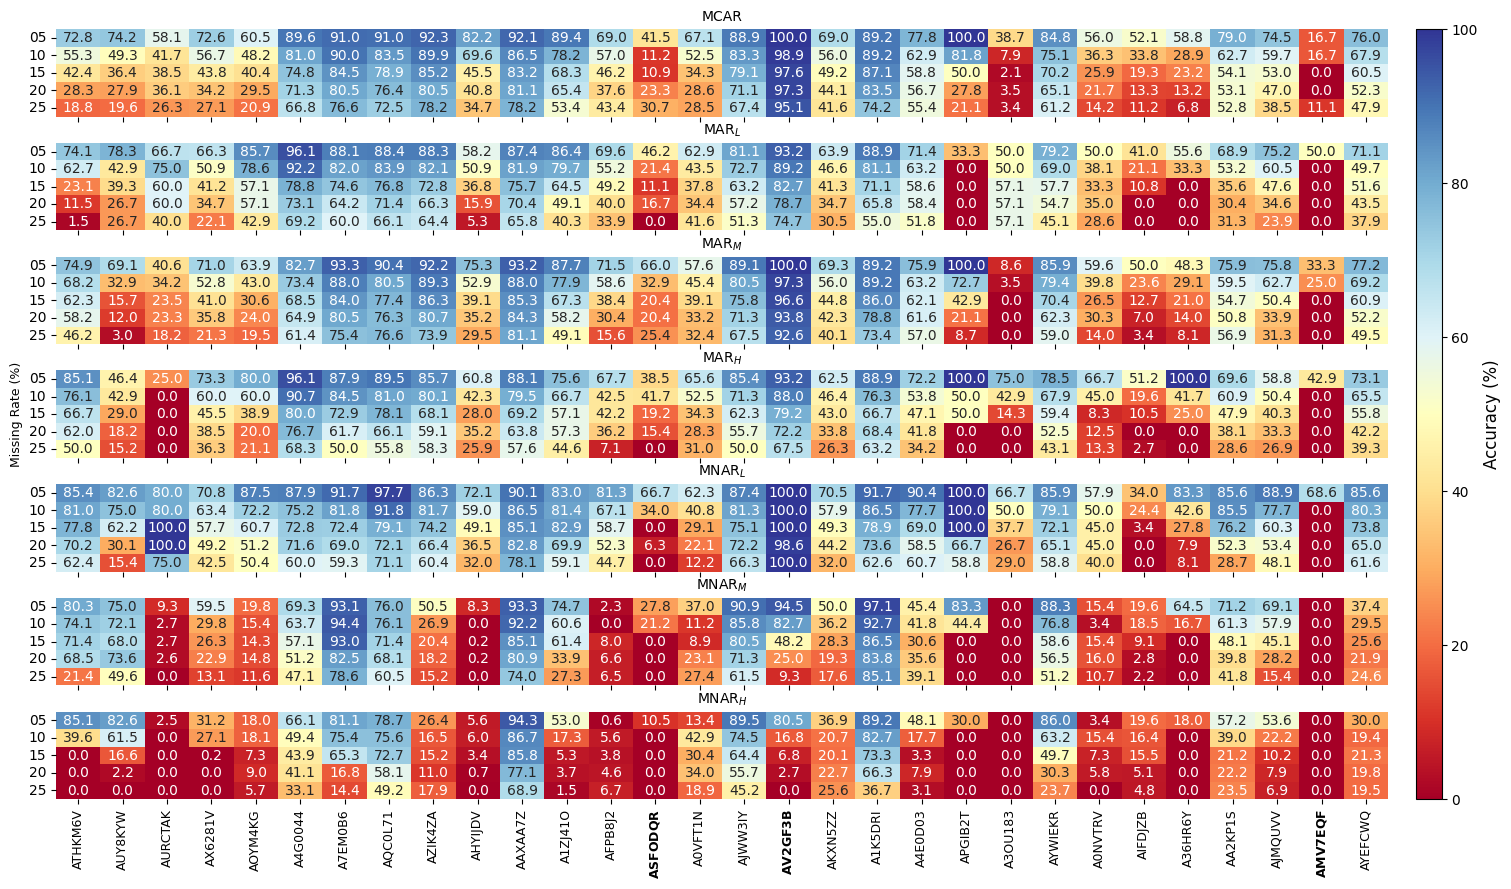

In [11]:
#results_hros.plot_heatmap("Accuracy")
plot_heatmap(results_hros,"Accuracy")
#results_hros.plot_heatmap("F1_Score")
# results_hros.plot_heatmap("Recall")
# results_hros.plot_heatmap("Precision")


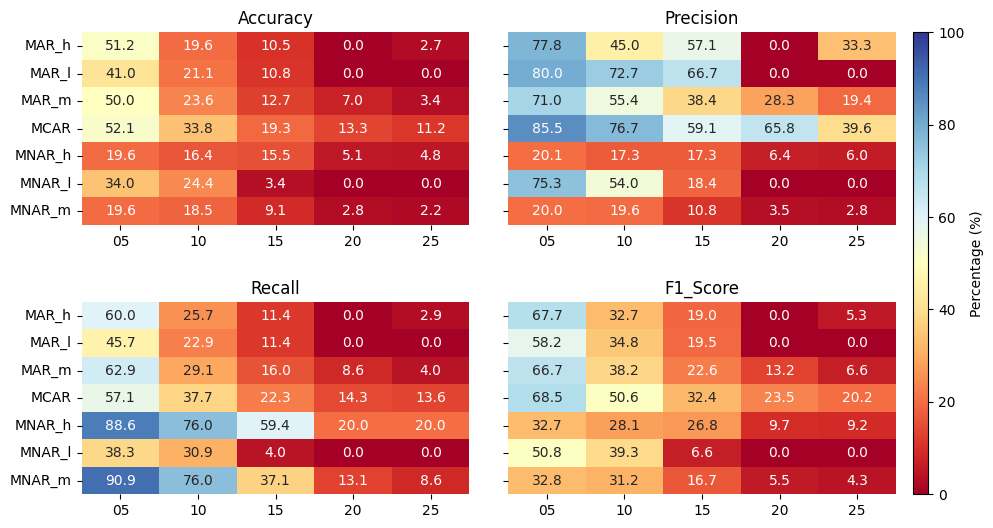

In [18]:
results_hros.plot_pheatmap()